In [1]:
# Imports
import time
import json
import matplotlib.pyplot as plt # type: ignore
import pyvisa # type: ignore
import numpy as np # type: ignore
import scipy # type: ignore
from numpy import random # type: ignore
from __future__ import annotations 
from typing import TYPE_CHECKING, Callable
from qcodes.instrument import find_or_create_instrument # type: ignore
from qblox_instruments import Cluster, ClusterType # type: ignore
if TYPE_CHECKING:
    from qblox_instruments.qcodes_drivers.module import Module # type: ignore
import sys
sys.path.append(r"C:\\Users\\BaughLaflamme\\Desktop\\Qblox Master Folder\\Cluster\\Libraries\\Qblox Sequence Helper")
import sequence_helper as sh

In [2]:
cluster_ip = "192.168.137.2"
cluster_name = "cluster0"
cluster = find_or_create_instrument(
    Cluster,
    recreate=True,
    name=cluster_name,
    identifier=cluster_ip,
    dummy_cfg=(
        {
            2: ClusterType.CLUSTER_QCM,
            4: ClusterType.CLUSTER_QRM,
            6: ClusterType.CLUSTER_QCM_RF,
        }
        if cluster_ip is None
        else None
    ),
)
cluster.led_brightness('medium') # Sets LED brightness on the modules. Options are 'low', 'medium' and 'high'
# Get modules, and connect to the QRM
def get_connected_modules(cluster: Cluster, filter_fn: Callable | None = None) -> dict[int, Module]:
    def checked_filter_fn(mod: ClusterType) -> bool:
        if filter_fn is not None:
            return filter_fn(mod)
        return True
    return {
        mod.slot_idx: mod for mod in cluster.modules if mod.present() and checked_filter_fn(mod)
    }
modules = get_connected_modules(cluster)
module = list(modules.values())[0]
cluster.reset()
print(cluster.get_system_status())
qrm_module = modules[4]
qcm_module = modules[2]
rf_module = modules[6]
rm = pyvisa.ResourceManager()
scope = rm.open_resource('GPIB0::8::INSTR')

Status: OKAY, Flags: NONE, Slot flags: NONE


In [8]:
# Setting the oscilloscope ranges
scope.write(f'TIME_DIV {5000e-9} S')	# Set the time scale on all oscilloscope channels
scope.write(f'C1:VOLT_DIV {0.1} V')	    # Set the voltage scale on channel 1
scope.write(f'C2:VOLT_DIV {0.1} V')	    # Set the voltage scale on channel 2
scope.write(f'TRIG_DELAY {0}')		# Set the time scale left/right on the display
scope.write(f'TRIG_MODE NORMAL')		# Set the trigger mode to "single" in order to take one acquisition

18

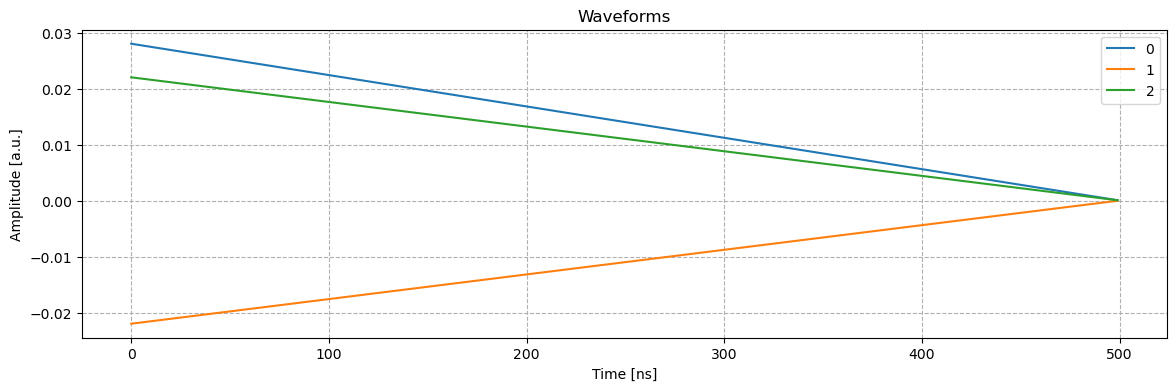

Sequence:

	wait_sync	4
	set_awg_offs	917,917
	upd_param	5000
	set_awg_offs	0,0
	play	0,0,500
	set_awg_offs	0,0
	upd_param	5000
	set_awg_offs	721,721
	play	1,1,500
	set_awg_offs	0,0
	play	2,2,500
	set_awg_offs	0,0
	upd_param	4
	stop


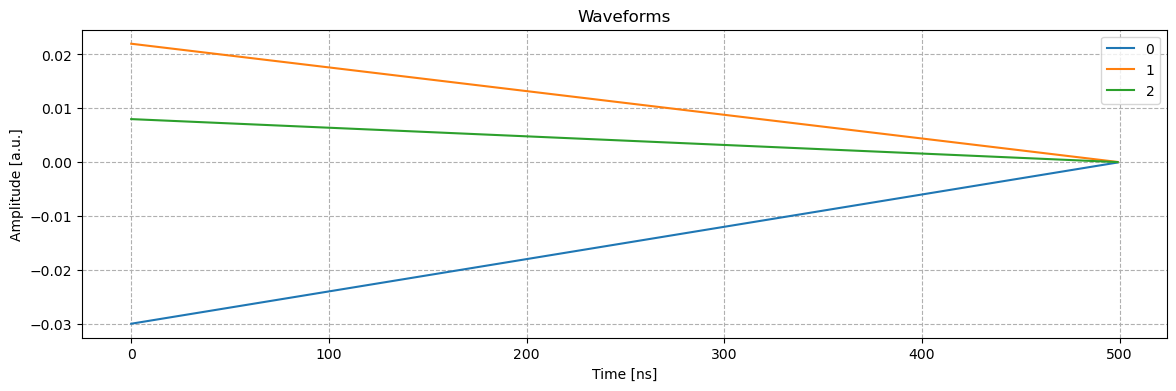

Sequence:

	wait_sync	4
	set_awg_offs	0,0
	upd_param	5000
	set_awg_offs	983,983
	play	0,0,500
	set_awg_offs	983,983
	upd_param	5000
	set_awg_offs	262,262
	play	1,1,500
	set_awg_offs	0,0
	play	2,2,500
	set_awg_offs	0,0
	upd_param	4
	stop


In [9]:
# Defining Parameters for Fast Pulsing, the RF Pulse, and Aqcuisition

DC_output_sequence_0 = [
	['square', 5000, 0.07],
	['ramp', 500, 0.07, 0],
	['square', 5000, 0], # Wait for Dephasing
	['ramp', 500, 0, 0.055],
	['ramp', 500, 0.055, 0]
]

DC_output_sequence_1 = [
	['square', 5000, 0],
	['ramp', 500, 0, 0.075],
	['square', 5000, 0.075], # Wait for Dephasing
	['ramp', 500, 0.075, 0.02],
	['ramp', 500, 0.02, 0]
]

acquisitions = ['acq', 8000, 16384]



num_loops = 1

# Load sequences

qcm_module.sequencer0.sequence(sh.make_output_sequence(input = DC_output_sequence_0, module = 'qcm', iterations = num_loops, plot = True))
qcm_module.sequencer1.sequence(sh.make_output_sequence(input = DC_output_sequence_1, module = 'qcm', iterations = num_loops, plot = True))
# rf_module.sequencer0.sequence(sh.make_rf_sequence(RF_output_sequence_0, marker = 0, iterations = num_loops))
qrm_module.sequencer0.sequence(sh.make_input_sequence(input = acquisitions, iterations = num_loops))
rf_module.sequencer0.sequence(sh.marker_only_sequence())


sh.disconnect_io(rf_module)
sh.disconnect_io(qcm_module)
sh.disconnect_io(qrm_module)


# Connect to output and input ports
sh.connect_output(module = qcm_module, sequencer = 0, output_index = 0, path = 0)
sh.connect_output(module = qcm_module, sequencer = 1, output_index = 1, path = 0)
# sh.connect_rf_output(module = rf_module, sequencer = 0, output_index = 0, nco_freq = 50e6, lo_freq = 2e9)
sh.connect_input(module = qrm_module, sequencer = 0, input_index = 0, path = 0)
rf_module.sequencer0.sync_en(True)

# Finally, arm all sequencers
qcm_module.arm_sequencer(0)
qcm_module.arm_sequencer(1)
qrm_module.arm_sequencer(0)
rf_module.arm_sequencer(0)

# Start the sequence
cluster.start_sequencer()